In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
plt.rcParams['figure.figsize']=[10,5]

In [2]:
ecg_label = pd.read_csv('/Users/peddireddysriram/Desktop/IFN 703, Advanced Project/Python/data/training.csv')

In [3]:
ecg_label.head()

,filename,label
0,A01823,normal
1,A05482,normal
2,A06114,normal
3,A04275,normal
4,A01157,normal


In [4]:
ecg_label.shape

(4060, 2)

In [5]:
# Checking if all the the readings are normal.
ecg_label.isna().sum().sort_values()

filename    0
label       0
dtype: int64

In [6]:
ecg_label['label'].value_counts(dropna = False)

normal    4060
Name: label, dtype: int64

# Objective importing matrix data from file. 

In [7]:
ecg = scipy.io.loadmat('/Users/peddireddysriram/Desktop/IFN 703, Advanced Project/Python/data/testing/A00004.mat')

In [8]:
print(ecg)

{'val': array([[519, 619, 723, ..., 116,  17,  18]], dtype=int16)}


In [9]:
type(ecg)

dict

In [10]:
# Extracting values from ecg.
ecg = ecg['val']

In [11]:
print(ecg)

[[519 619 723 ... 116  17  18]]


In [12]:
type(ecg)

numpy.ndarray

In [13]:
import os

In [14]:
# Find a way to import all files from the folder including header files.
directory = '/Users/peddireddysriram/Desktop/IFN 703, Advanced Project/Python/data/training'

# Initialize an empty list to store the data
train_data = []
file_names = []
# Loop through all files in the directory
for filename in os.listdir(directory):
    if filename.endswith('.mat'):
        # Construct the full path to the .mat file
        file_path = os.path.join(directory, filename)
        
        # Load the .mat file
        data = scipy.io.loadmat(file_path)
        
        # Append the loaded data to the list
        train_data.append(data)
        file_names.append(filename)

# Now, data_list contains the loaded data from all .mat files in the folder
ecg_df = pd.DataFrame(train_data)
ecg_df['File Names'] = file_names

In [15]:
ecg_df.head()

,val,File Names
0,"[[-489, -588, -687, -783, -860, -893, -887, -8...",A07848.mat
1,"[[21, 23, 28, 47, 60, 58, 47, 16, -46, -141, -...",A04399.mat
2,"[[196, 251, 316, 381, 439, 464, 477, 486, 485,...",A05087.mat
3,"[[-4, -5, -6, -7, -7, -7, -7, -7, -7, -6, -6, ...",A05939.mat
4,"[[-117, -152, -190, -231, -271, -301, -324, -3...",A00841.mat


In [16]:
ecg_df.dtypes

val           object
File Names    object
dtype: object

In [17]:
ecg_df['ecg_data'] = ecg_df['val']

In [18]:
type(ecg_df['val'][0])

numpy.ndarray

In [19]:
ecg_df['ecg_data'] = ecg_df['val']

In [20]:
ecg_df = ecg_df.drop(labels = ['val'], axis = 1)

In [21]:
ecg_df.head()

,File Names,ecg_data
0,A07848.mat,"[[-489, -588, -687, -783, -860, -893, -887, -8..."
1,A04399.mat,"[[21, 23, 28, 47, 60, 58, 47, 16, -46, -141, -..."
2,A05087.mat,"[[196, 251, 316, 381, 439, 464, 477, 486, 485,..."
3,A05939.mat,"[[-4, -5, -6, -7, -7, -7, -7, -7, -7, -6, -6, ..."
4,A00841.mat,"[[-117, -152, -190, -231, -271, -301, -324, -3..."


Calculate mean and standard deviation for each reading. ecg_df is used as reference alone. we have to build a model that takes ecg_data column alone.

In [22]:
ecg_mean = []
ecg_sd = []
for i in ecg_df['ecg_data']:
    ecg_mean.append(i.mean())
    ecg_sd.append(np.std(i))


In [23]:
print(ecg_sd)

[276.2701111611382, 221.13449385284864, 142.08783515018683, 171.27998790385456, 164.16910438784203, 88.79383280712827, 397.369666721689, 289.64983621087663, 151.91392039495733, 321.7310509794373, 194.25444772442768, 205.95107496178207, 153.15407718768012, 136.96271654724146, 78.93110979405388, 148.90257218516672, 355.4390259420969, 493.91373276431165, 618.4031779650985, 143.48696157757828, 172.61786253540856, 233.02497011325622, 289.1908805469835, 343.076616440766, 161.25439562547058, 175.6119406075527, 175.9656512239439, 248.23171489257, 470.0093897377654, 178.66437049107756, 311.87176538274605, 147.53773899866945, 111.18700975278287, 138.95406948243146, 178.70446902727693, 166.52276146439678, 174.93896074024377, 177.1455210949461, 138.5472233752364, 69.69051899170599, 106.03581762887211, 219.168035173984, 57.11335793245733, 445.0567621868967, 462.2407626743107, 108.94060819575833, 162.5266249890183, 113.67500211644088, 56.233293630920485, 88.23858951385762, 220.57681606656155, 189.89

In [24]:
print(ecg_mean)

[37.78888888888889, -37.76133333333333, 13.137, -29.337378157947086, -3.279777777777778, 6.181444444444445, 22.08077777777778, -3.836888888888889, -24.471888888888888, 40.153666666666666, 23.78363252375924, 13.381444444444444, 10.960888888888888, 18.00733333333333, 11.05788888888889, 4.876080061249043, -40.08533333333333, 18.51591723040191, 34.896, 13.754888888888889, 14.078388888888888, -5.561222222222222, 1.1771485018109977, 66.40266666666666, 15.779108175061932, -5.737777777777778, 14.317333333333334, 22.19677777777778, 23.235, -19.269572953736656, 26.85677777777778, 14.689777777777778, -0.35788888888888887, -2.5282222222222224, 22.28688888888889, -2.398222222222222, 3.3761111111111113, -11.066, -8.70711111111111, 1.5026666666666666, -12.315063385533184, 31.401555555555557, -8.911111111111111, 54.03477777777778, 12.649777777777778, 4.631222222222222, 1.1568888888888889, 3.542222222222222, -3.5269385699899294, 9.770777777777777, 29.630777777777777, 17.209666666666667, 13.985565593087

Varying mean and Standard deveation. We have to explore the effects of standardization and normalization. Although normalization would be ideal, Assumption is that normalization would improve the performance of the RF or Donut.

Build RF first then Auto Encoder then Donut.

First let us work on visulaizing a single reading.

I have an idea for visulaization. First visualize the first reading. To do this we need to use a line plot. X axis is required for this example. we know that each reading has 9000 data points. Readings are sampled at 300 Hz. this means the signal is 30 seconds long. so create an array with 0 to 9000 values in it.

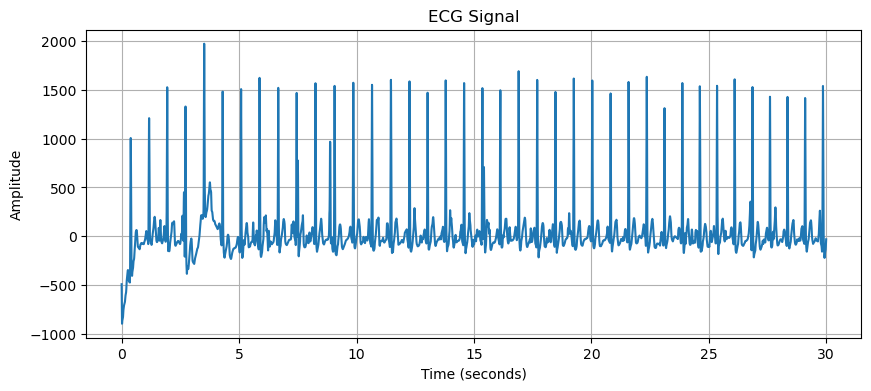

In [25]:
# Sampling frequency
sampling_freq = 300  # Hz

# Total number of readings
num_readings = 9000

# Time array (in seconds)
time = np.arange(num_readings) / sampling_freq

plt.figure(figsize=(10, 4))
plt.plot(time, ecg_df['ecg_data'][0][0])
plt.title('ECG Signal')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

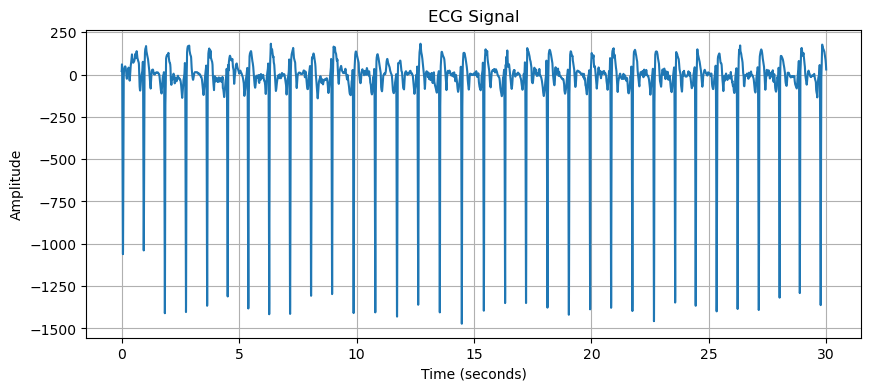

In [26]:
# Sampling frequency
sampling_freq = 300  # Hz

# Total number of readings
num_readings = 9000

# Time array (in seconds)
time = np.arange(num_readings) / sampling_freq

plt.figure(figsize=(10, 4))
plt.plot(time, ecg_df['ecg_data'][1][0])
plt.title('ECG Signal')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

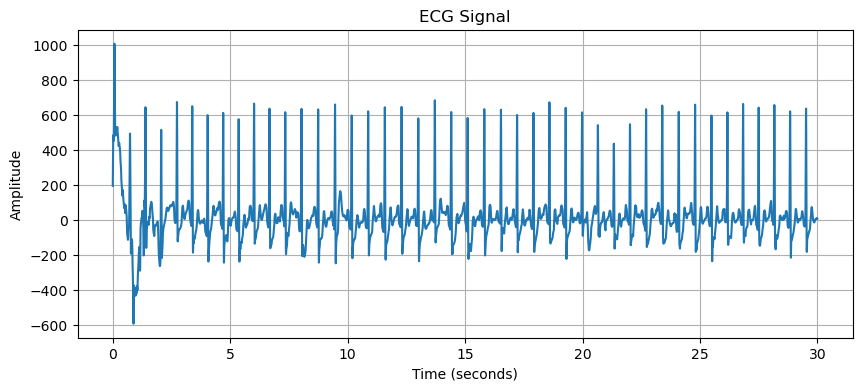

In [27]:
# Sampling frequency
sampling_freq = 300  # Hz

# Total number of readings
num_readings = 9000

# Time array (in seconds)
time = np.arange(num_readings) / sampling_freq

plt.figure(figsize=(10, 4))
plt.plot(time, ecg_df['ecg_data'][2][0])
plt.title('ECG Signal')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

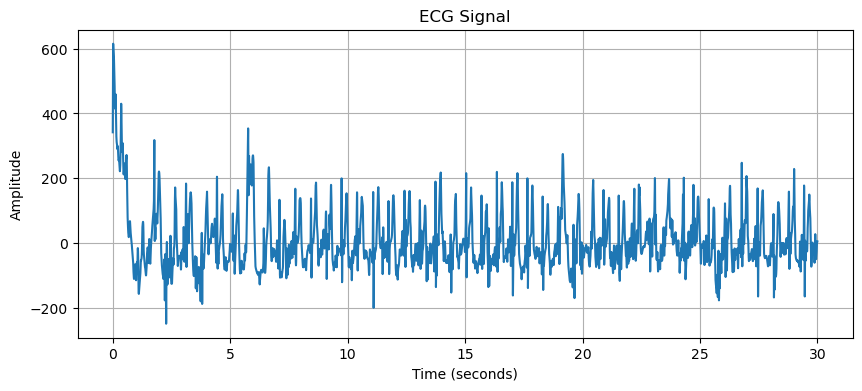

In [28]:
# Sampling frequency
sampling_freq = 300  # Hz

# Total number of readings
num_readings = 9000

# Time array (in seconds)
time = np.arange(num_readings) / sampling_freq

plt.figure(figsize=(10, 4))
plt.plot(time, ecg_df['ecg_data'][5][0])
plt.title('ECG Signal')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

Since Visuliazation is done we can see the effect of normalization.

In [29]:
normalized_signal = (ecg_df['ecg_data'][1][0] - np.min(ecg_df['ecg_data'][1][0])) / (np.max(ecg_df['ecg_data'][1][0]) - np.min(ecg_df['ecg_data'][1][0]))

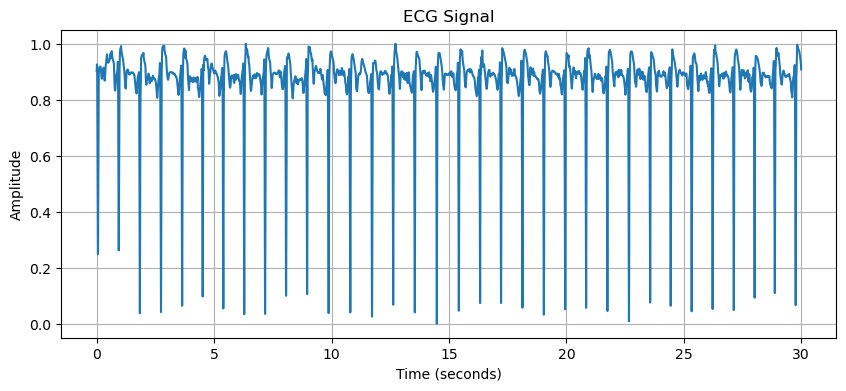

In [30]:
# Sampling frequency
sampling_freq = 300  # Hz

# Total number of readings
num_readings = 9000

# Time array (in seconds)
time = np.arange(num_readings) / sampling_freq

plt.figure(figsize=(10, 4))
plt.plot(time, normalized_signal)
plt.title('ECG Signal')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

Normalization is working. Let us further test this in the model building phase.

Let us build a function for normalization. Store this function in a new column in the df.

In [31]:
def normalize_data(data):
    # Assuming you want to normalize each row independently
    normalized_data = (data - data.min()) / (data.max() - data.min())
    return normalized_data

# Apply the normalization function to each row of the DataFrame and save the results in a new column
ecg_df['normalized_data'] = ecg_df['ecg_data'].apply(normalize_data)


In [32]:
ecg_df.head()

,File Names,ecg_data,normalized_data
0,A07848.mat,"[[-489, -588, -687, -783, -860, -893, -887, -8...","[[0.14116002795248078, 0.10656883298392732, 0...."
1,A04399.mat,"[[21, 23, 28, 47, 60, 58, 47, 16, -46, -141, -...","[[0.9026602176541717, 0.903869407496977, 0.906..."
2,A05087.mat,"[[196, 251, 316, 381, 439, 464, 477, 486, 485,...","[[0.49218261413383363, 0.5265791119449656, 0.5..."
3,A05939.mat,"[[-4, -5, -6, -7, -7, -7, -7, -7, -7, -6, -6, ...","[[0.4492512479201331, 0.44841930116472545, 0.4..."
4,A00841.mat,"[[-117, -152, -190, -231, -271, -301, -324, -3...","[[0.44339622641509435, 0.41799709724238027, 0...."


We have succesfully added the new normalized ECG signal data to the file.

We also have seen previously that not all the readings have 9000 values in it. we have to check the validity of this in the dataset.

In [33]:
size = []
true = 0
false = 0
for i in ecg_df['ecg_data']:
    j = 9000
    if len(i[0]) == j:
        size.append(True)
        true = true + 1
    else:
        size.append(False)
        false = false + 1

In [34]:
print(size)
print(true, false)

[True, True, True, False, True, True, True, True, True, True, False, True, True, True, True, False, True, False, True, True, False, True, False, True, False, True, True, True, True, False, True, True, True, True, False, True, True, True, True, True, False, True, True, True, True, True, True, False, False, True, True, True, False, False, True, True, True, False, False, False, True, True, True, False, True, True, False, True, True, True, True, False, False, True, True, False, True, True, True, True, True, True, True, True, True, True, False, False, True, False, True, True, False, False, True, False, True, True, True, False, True, True, True, True, True, True, True, False, True, True, True, True, False, False, False, True, True, False, True, True, False, False, False, True, True, True, False, True, False, False, True, True, True, False, True, True, True, True, False, False, True, True, True, True, False, False, True, True, True, False, True, True, True, True, False, False, True, True, Tru

This proves that all the values in the dataset are not values are exactly 9000 in length there are exactly 2957 that are 9000 in length and 1103 are not.

In [35]:
file_path = '/Users/peddireddysriram/Desktop/IFN 703, Advanced Project/Python/data/training/A05939.hea'

# Read the contents of the .hea file
with open(file_path, 'r') as file:
    contents = file.read()

# Print the contents
print(contents)

A05939 1 300 10054 01:19:00 1/09/2000 
A05939.mat 16+24 1000/mV 16 0 -4 0 0 ECG 



In [36]:
ecg_df.head()

,File Names,ecg_data,normalized_data
0,A07848.mat,"[[-489, -588, -687, -783, -860, -893, -887, -8...","[[0.14116002795248078, 0.10656883298392732, 0...."
1,A04399.mat,"[[21, 23, 28, 47, 60, 58, 47, 16, -46, -141, -...","[[0.9026602176541717, 0.903869407496977, 0.906..."
2,A05087.mat,"[[196, 251, 316, 381, 439, 464, 477, 486, 485,...","[[0.49218261413383363, 0.5265791119449656, 0.5..."
3,A05939.mat,"[[-4, -5, -6, -7, -7, -7, -7, -7, -7, -6, -6, ...","[[0.4492512479201331, 0.44841930116472545, 0.4..."
4,A00841.mat,"[[-117, -152, -190, -231, -271, -301, -324, -3...","[[0.44339622641509435, 0.41799709724238027, 0...."


In [38]:
ecg_df['length'] = 0

In [39]:
ecg_df.head()

,File Names,ecg_data,normalized_data,length
0,A07848.mat,"[[-489, -588, -687, -783, -860, -893, -887, -8...","[[0.14116002795248078, 0.10656883298392732, 0....",0
1,A04399.mat,"[[21, 23, 28, 47, 60, 58, 47, 16, -46, -141, -...","[[0.9026602176541717, 0.903869407496977, 0.906...",0
2,A05087.mat,"[[196, 251, 316, 381, 439, 464, 477, 486, 485,...","[[0.49218261413383363, 0.5265791119449656, 0.5...",0
3,A05939.mat,"[[-4, -5, -6, -7, -7, -7, -7, -7, -7, -6, -6, ...","[[0.4492512479201331, 0.44841930116472545, 0.4...",0
4,A00841.mat,"[[-117, -152, -190, -231, -271, -301, -324, -3...","[[0.44339622641509435, 0.41799709724238027, 0....",0


In [40]:
count = 0
for i in ecg_df['ecg_data']:
    ecg_df['length'][count] = len(i[0])
    count = count+1

In [41]:
ecg_df.head()

,File Names,ecg_data,normalized_data,length
0,A07848.mat,"[[-489, -588, -687, -783, -860, -893, -887, -8...","[[0.14116002795248078, 0.10656883298392732, 0....",9000
1,A04399.mat,"[[21, 23, 28, 47, 60, 58, 47, 16, -46, -141, -...","[[0.9026602176541717, 0.903869407496977, 0.906...",9000
2,A05087.mat,"[[196, 251, 316, 381, 439, 464, 477, 486, 485,...","[[0.49218261413383363, 0.5265791119449656, 0.5...",9000
3,A05939.mat,"[[-4, -5, -6, -7, -7, -7, -7, -7, -7, -6, -6, ...","[[0.4492512479201331, 0.44841930116472545, 0.4...",10054
4,A00841.mat,"[[-117, -152, -190, -231, -271, -301, -324, -3...","[[0.44339622641509435, 0.41799709724238027, 0....",9000


In [42]:
ecg_df['File Names'][0].split('.')[0]

'A07848'

In [43]:
for i in range(0, ecg_df.shape[0]):
    ecg_df['File Names'][i] = ecg_df['File Names'][i].split('.')[0]

ecg_df.head()

,File Names,ecg_data,normalized_data,length
0,A07848,"[[-489, -588, -687, -783, -860, -893, -887, -8...","[[0.14116002795248078, 0.10656883298392732, 0....",9000
1,A04399,"[[21, 23, 28, 47, 60, 58, 47, 16, -46, -141, -...","[[0.9026602176541717, 0.903869407496977, 0.906...",9000
2,A05087,"[[196, 251, 316, 381, 439, 464, 477, 486, 485,...","[[0.49218261413383363, 0.5265791119449656, 0.5...",9000
3,A05939,"[[-4, -5, -6, -7, -7, -7, -7, -7, -7, -6, -6, ...","[[0.4492512479201331, 0.44841930116472545, 0.4...",10054
4,A00841,"[[-117, -152, -190, -231, -271, -301, -324, -3...","[[0.44339622641509435, 0.41799709724238027, 0....",9000


Adding an additional column Length would help with splitting the signal later on.

In [48]:
print(min(ecg_df['length']))
print(max(ecg_df['length']))

2714
18286


As displayed the smallest signal length is less than 3000 and the largest is almost 18000.

In [49]:
ecg_df[ecg_df['length']<3000]

,File Names,ecg_data,normalized_data,length
342,A04239,"[[-36, -48, -54, -59, -61, -63, -66, -69, -71,...","[[0.1023778071334214, 0.09445178335535007, 0.0...",2812
928,A05493,"[[-66, -71, -75, -78, -80, -81, -77, -70, -59,...","[[0.7182186234817813, 0.71417004048583, 0.7109...",2714
1942,A07595,"[[191, 230, 268, 308, 331, 339, 344, 346, 345,...","[[0.793662490788504, 0.8224023581429624, 0.850...",2992
2103,A02345,"[[9, 10, 11, 13, 14, 15, 18, 22, 28, 34, 40, 4...","[[0.1238716148445336, 0.12437311935807423, 0.1...",2870
2655,A05148,"[[110, 141, 172, 208, 229, 240, 249, 255, 260,...","[[0.4096271826333176, 0.4242567248702218, 0.43...",2956
3028,A07615,"[[-97, -113, -130, -152, -179, -195, -203, -20...","[[0.5621345029239766, 0.5504385964912281, 0.53...",2766
3517,A07499,"[[-25, -27, -29, -31, -32, -33, -35, -37, -39,...","[[0.3620689655172414, 0.35893416927899685, 0.3...",2928
3674,A01364,"[[59, 74, 93, 114, 129, 148, 175, 199, 214, 22...","[[0.51698670605613, 0.5243722304283605, 0.5337...",2796
3738,A05499,"[[-18, -19, -21, -23, -25, -27, -29, -31, -32,...","[[0.533181429792082, 0.5328966106522358, 0.532...",2742


There are more than one signal that are smaller than 3000.

# Test Data

Creating a similar dataset with test data.

In [51]:
# Find a way to import all files from the folder including header files.
directory = '/Users/peddireddysriram/Desktop/IFN 703, Advanced Project/Python/data/testing'

# Initialize an empty list to store the data
train_data = []
file_names = []
# Loop through all files in the directory
for filename in os.listdir(directory):
    if filename.endswith('.mat'):
        # Construct the full path to the .mat file
        file_path = os.path.join(directory, filename)
        
        # Load the .mat file
        data = scipy.io.loadmat(file_path)
        
        # Append the loaded data to the list
        train_data.append(data)
        file_names.append(filename)

# Now, data_list contains the loaded data from all .mat files in the folder
ecg_test = pd.DataFrame(train_data)
ecg_test['File Names'] = file_names

In [52]:
ecg_test.head(10)

,val,File Names
0,"[[464, 610, 677, 673, 586, 434, 253, 78, -67, ...",A07690.mat
1,"[[93, 108, 118, 127, 134, 137, 133, 124, 115, ...",A02930.mat
2,"[[71, 88, 95, 100, 105, 109, 114, 117, 120, 12...",A03390.mat
3,"[[-426, -511, -595, -675, -730, -750, -757, -7...",A00699.mat
4,"[[163, 195, 231, 270, 304, 316, 321, 324, 328,...",A01587.mat
5,"[[15, 16, 19, 22, 25, 28, 30, 32, 35, 36, 33, ...",A00855.mat
6,"[[-312, -373, -434, -495, -541, -559, -564, -5...",A05093.mat
7,"[[16, 23, 33, 38, 36, 29, 22, 15, 7, 0, -4, -3...",A05911.mat
8,"[[179, 206, 230, 249, 261, 271, 272, 265, 262,...",A00869.mat
9,"[[-134, -168, -205, -245, -280, -302, -316, -3...",A07860.mat


In [53]:
ecg_test['ecg_data'] = ecg_test['val']
ecg_test = ecg_test.drop(labels = ['val'], axis = 1)
ecg_test['normalized_data'] = ecg_test['ecg_data'].apply(normalize_data)
ecg_test['length'] = 0
count = 0
for i in ecg_test['ecg_data']:
    ecg_test['length'][count] = len(i[0])
    count = count+1

In [54]:
ecg_test.shape

(4468, 4)

In [56]:
ecg_test[ecg_test['length']<3000]

,File Names,ecg_data,normalized_data,length
550,A00894.mat,"[[-269, -319, -352, -391, -412, -418, -422, -4...","[[0.14516129032258066, 0.09772296015180265, 0....",2868
2071,A00984.mat,"[[-143, -171, -202, -235, -261, -269, -272, -2...","[[0.35136986301369866, 0.3321917808219178, 0.3...",2808
2545,A01049.mat,"[[67, 90, 105, 117, 126, 133, 137, 136, 131, 1...","[[0.8147659854976929, 0.8299274884640738, 0.83...",2902
2570,A00592.mat,"[[-115, -123, -131, -135, -132, -121, -102, -7...","[[0.3866758241758242, 0.38118131868131866, 0.3...",2996
2662,A02179.mat,"[[-108, -79, -33, 17, 80, 164, 287, 394, 452, ...","[[0.3169845594913715, 0.3257644565546473, 0.33...",2832
2738,A08050.mat,"[[-4, -3, -2, -1, 0, 0, 0, 3, 8, 13, 18, 23, 2...","[[0.7252066115702479, 0.7262396694214877, 0.72...",2738
3601,A06948.mat,"[[-206, -236, -268, -301, -320, -329, -336, -3...","[[0.29677819083023543, 0.2781908302354399, 0.2...",2848


There are several signals smaller than 3000 in the test set as well

In [58]:

for i in range(0, ecg_test.shape[0]):
    ecg_test['File Names'][i] = ecg_test['File Names'][i].split('.')[0]

ecg_test.head()

,File Names,ecg_data,normalized_data,length
0,A07690,"[[464, 610, 677, 673, 586, 434, 253, 78, -67, ...","[[0.6144615384615385, 0.6593846153846153, 0.68...",9000
1,A02930,"[[93, 108, 118, 127, 134, 137, 133, 124, 115, ...","[[0.17055655296229802, 0.18402154398563733, 0....",9000
2,A03390,"[[71, 88, 95, 100, 105, 109, 114, 117, 120, 12...","[[0.44107744107744107, 0.4696969696969697, 0.4...",9000
3,A00699,"[[-426, -511, -595, -675, -730, -750, -757, -7...","[[0.16497263487099295, 0.13174354964816262, 0....",9000
4,A01587,"[[163, 195, 231, 270, 304, 316, 321, 324, 328,...","[[0.6425582785415421, 0.661685594739988, 0.683...",18000


## Importing Labels for test data

In [59]:
labels = pd.read_csv('/Users/peddireddysriram/Desktop/IFN 703, Advanced Project/Python/data/testing.csv')
labels['File Names'] = labels['filename']
labels.head()

,filename,label,File Names
0,A02083,normal,A02083
1,A08474,normal,A08474
2,A03133,normal,A03133
3,A01743,normal,A01743
4,A06930,normal,A06930


In [60]:
labels['label'].value_counts()

other     2415
normal    1016
af         758
noisy      279
Name: label, dtype: int64

In [61]:
ecg_test = pd.merge(ecg_test, labels, on='File Names', how='inner')
ecg_test.head()

,File Names,ecg_data,normalized_data,length,filename,label
0,A07690,"[[464, 610, 677, 673, 586, 434, 253, 78, -67, ...","[[0.6144615384615385, 0.6593846153846153, 0.68...",9000,A07690,normal
1,A02930,"[[93, 108, 118, 127, 134, 137, 133, 124, 115, ...","[[0.17055655296229802, 0.18402154398563733, 0....",9000,A02930,normal
2,A03390,"[[71, 88, 95, 100, 105, 109, 114, 117, 120, 12...","[[0.44107744107744107, 0.4696969696969697, 0.4...",9000,A03390,normal
3,A00699,"[[-426, -511, -595, -675, -730, -750, -757, -7...","[[0.16497263487099295, 0.13174354964816262, 0....",9000,A00699,other
4,A01587,"[[163, 195, 231, 270, 304, 316, 321, 324, 328,...","[[0.6425582785415421, 0.661685594739988, 0.683...",18000,A01587,other


# Back to train data

In [63]:
count = 0
for i in ecg_df['normalized_data']:
    ecg_df['normalized_data'][count] = i[0]
    count = count+1

In [64]:
ecg_df.head()

,File Names,ecg_data,normalized_data,length
0,A07848,"[[-489, -588, -687, -783, -860, -893, -887, -8...","[0.14116002795248078, 0.10656883298392732, 0.0...",9000
1,A04399,"[[21, 23, 28, 47, 60, 58, 47, 16, -46, -141, -...","[0.9026602176541717, 0.903869407496977, 0.9068...",9000
2,A05087,"[[196, 251, 316, 381, 439, 464, 477, 486, 485,...","[0.49218261413383363, 0.5265791119449656, 0.56...",9000
3,A05939,"[[-4, -5, -6, -7, -7, -7, -7, -7, -7, -6, -6, ...","[0.4492512479201331, 0.44841930116472545, 0.44...",10054
4,A00841,"[[-117, -152, -190, -231, -271, -301, -324, -3...","[0.44339622641509435, 0.41799709724238027, 0.3...",9000


In [65]:
print((ecg_df['normalized_data'][0][0:3000]))
print((ecg_df['normalized_data'][0][3000:]))
print(type(len(ecg_df['normalized_data'][0][3000:6000])))

[0.14116003 0.10656883 0.07197764 ... 0.30153739 0.30363382 0.30573026]
[0.30782669 0.30992313 0.31132075 ... 0.28825996 0.29454927 0.30153739]
<class 'int'>


Splitting the data into windows with 3000 recordings each. we are making 2 subsets here.

In [67]:
column_names = ['File Names', 'normalized_data', 'length']
ecg_set1 = pd.DataFrame(columns=column_names)
#ecg_set2 = pd.DataFrame(columns=column_names)
print(ecg_set1.shape)
#print(ecg_set2.shape)

(0, 3)


In [68]:
# Subset 1
count1 = 0
for i in ecg_df['normalized_data']:
    if len(i)>=18000:
        ecg_set1 = ecg_set1.append({'File Names': ecg_df['File Names'][count1],'normalized_data':i[0:3000],'length':3000}, ignore_index=True)
        ecg_set1 = ecg_set1.append({'File Names': ecg_df['File Names'][count1],'normalized_data':i[3000:6000],'length':3000}, ignore_index=True)
        ecg_set1 = ecg_set1.append({'File Names': ecg_df['File Names'][count1],'normalized_data':i[6000:9000],'length':3000}, ignore_index=True)
        ecg_set1 = ecg_set1.append({'File Names': ecg_df['File Names'][count1],'normalized_data':i[9000:12000],'length':3000}, ignore_index=True)
        ecg_set1 = ecg_set1.append({'File Names': ecg_df['File Names'][count1],'normalized_data':i[12000:15000],'length':3000}, ignore_index=True)
        ecg_set1 = ecg_set1.append({'File Names': ecg_df['File Names'][count1],'normalized_data':i[15000:18000],'length':3000}, ignore_index=True)
    elif len(i)>=15000:
        ecg_set1 = ecg_set1.append({'File Names': ecg_df['File Names'][count1],'normalized_data':i[0:3000],'length':3000}, ignore_index=True)
        ecg_set1 = ecg_set1.append({'File Names': ecg_df['File Names'][count1],'normalized_data':i[3000:6000],'length':3000}, ignore_index=True)
        ecg_set1 = ecg_set1.append({'File Names': ecg_df['File Names'][count1],'normalized_data':i[6000:9000],'length':3000}, ignore_index=True)
        ecg_set1 = ecg_set1.append({'File Names': ecg_df['File Names'][count1],'normalized_data':i[9000:12000],'length':3000}, ignore_index=True)
        ecg_set1 = ecg_set1.append({'File Names': ecg_df['File Names'][count1],'normalized_data':i[12000:15000],'length':3000}, ignore_index=True)
    elif len(i)>=12000:
        ecg_set1 = ecg_set1.append({'File Names': ecg_df['File Names'][count1],'normalized_data':i[0:3000],'length':3000}, ignore_index=True)
        ecg_set1 = ecg_set1.append({'File Names': ecg_df['File Names'][count1],'normalized_data':i[3000:6000],'length':3000}, ignore_index=True)
        ecg_set1 = ecg_set1.append({'File Names': ecg_df['File Names'][count1],'normalized_data':i[6000:9000],'length':3000}, ignore_index=True)
        ecg_set1 = ecg_set1.append({'File Names': ecg_df['File Names'][count1],'normalized_data':i[9000:12000],'length':3000}, ignore_index=True)
    elif len(i)>=9000:
        ecg_set1 = ecg_set1.append({'File Names': ecg_df['File Names'][count1],'normalized_data':i[0:3000],'length':3000}, ignore_index=True)
        ecg_set1 = ecg_set1.append({'File Names': ecg_df['File Names'][count1],'normalized_data':i[3000:6000],'length':3000}, ignore_index=True)
        ecg_set1 = ecg_set1.append({'File Names': ecg_df['File Names'][count1],'normalized_data':i[6000:9000],'length':3000}, ignore_index=True)
    elif len(i)>=6000:
        ecg_set1 = ecg_set1.append({'File Names': ecg_df['File Names'][count1],'normalized_data':i[0:3000],'length':3000}, ignore_index=True)
        ecg_set1 = ecg_set1.append({'File Names': ecg_df['File Names'][count1],'normalized_data':i[3000:6000],'length':3000}, ignore_index=True)
    elif len(i)>=3000:
        ecg_set1 = ecg_set1.append({'File Names': ecg_df['File Names'][count1],'normalized_data':i[0:3000],'length':3000}, ignore_index=True)

    count1 = count1+1
        

In [69]:
print(ecg_set1.head(10))
print(ecg_set1.shape)

  File Names                                    normalized_data length
0     A07848  [0.14116002795248078, 0.10656883298392732, 0.0...   3000
1     A07848  [0.30782669461914747, 0.30992313067784766, 0.3...   3000
2     A07848  [0.2973445143256464, 0.2994409503843466, 0.302...   3000
3     A04399  [0.9026602176541717, 0.903869407496977, 0.9068...   3000
4     A04399  [0.966142684401451, 0.9655380894800484, 0.9643...   3000
5     A04399  [0.9504232164449818, 0.9558645707376058, 0.960...   3000
6     A05087  [0.49218261413383363, 0.5265791119449656, 0.56...   3000
7     A05087  [0.4058786741713571, 0.4058786741713571, 0.405...   3000
8     A05087  [0.4046278924327705, 0.3533458411507192, 0.325...   3000
9     A05939  [0.4492512479201331, 0.44841930116472545, 0.44...   3000
(12636, 3)


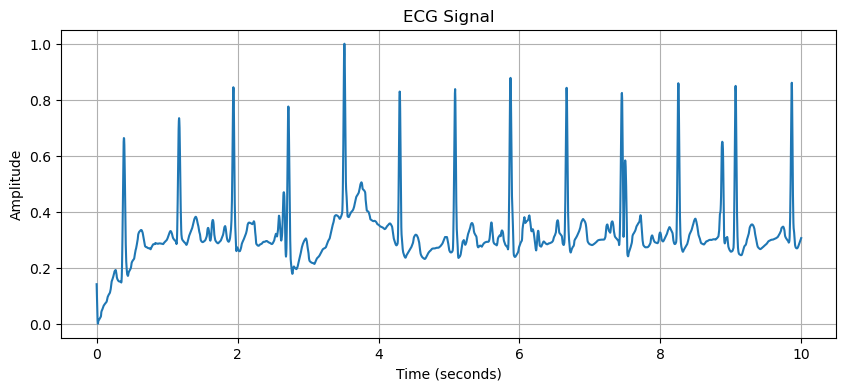

In [70]:
# Sampling frequency
sampling_freq = 300  # Hz

# Total number of readings
num_readings = 3000

# Time array (in seconds)
time = np.arange(num_readings) / sampling_freq

plt.figure(figsize=(10, 4))
plt.plot(time, ecg_set1['normalized_data'][0])
plt.title('ECG Signal')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

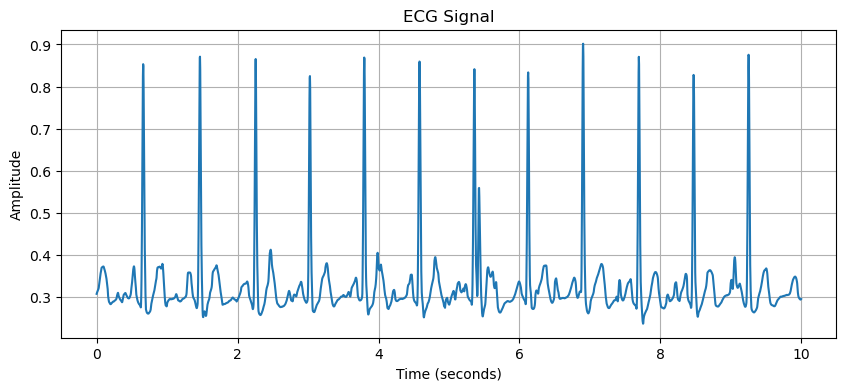

In [71]:
# Sampling frequency
sampling_freq = 300  # Hz

# Total number of readings
num_readings = 3000

# Time array (in seconds)
time = np.arange(num_readings) / sampling_freq

plt.figure(figsize=(10, 4))
plt.plot(time, ecg_set1['normalized_data'][1])
plt.title('ECG Signal')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

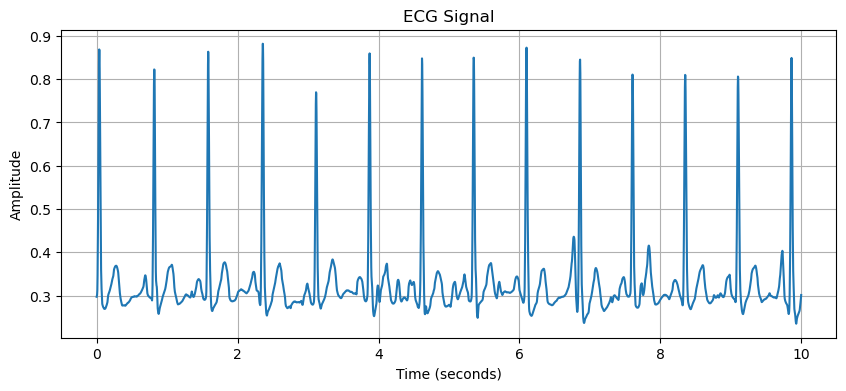

In [72]:
# Sampling frequency
sampling_freq = 300  # Hz

# Total number of readings
num_readings = 3000

# Time array (in seconds)
time = np.arange(num_readings) / sampling_freq

plt.figure(figsize=(10, 4))
plt.plot(time, ecg_set1['normalized_data'][2])
plt.title('ECG Signal')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

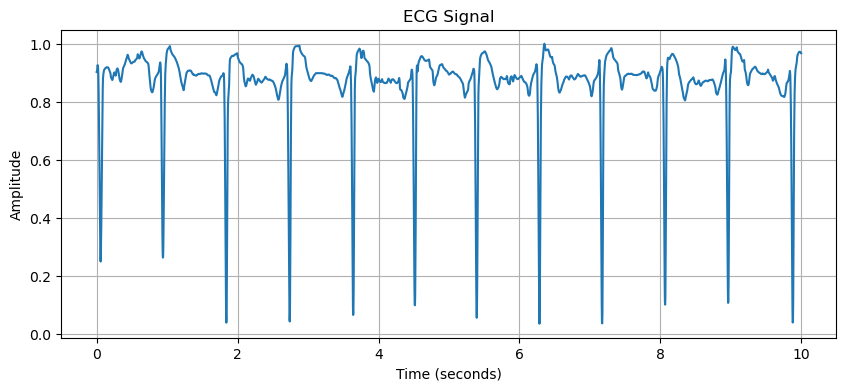

In [73]:
# Sampling frequency
sampling_freq = 300  # Hz

# Total number of readings
num_readings = 3000

# Time array (in seconds)
time = np.arange(num_readings) / sampling_freq

plt.figure(figsize=(10, 4))
plt.plot(time, ecg_set1['normalized_data'][3])
plt.title('ECG Signal')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

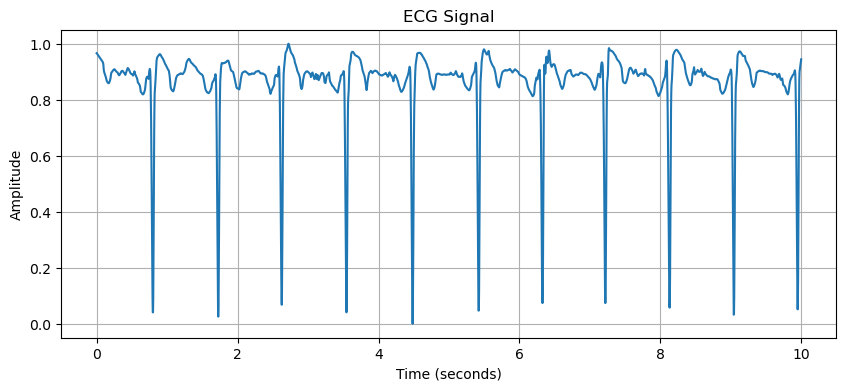

In [74]:
# Sampling frequency
sampling_freq = 300  # Hz

# Total number of readings
num_readings = 3000

# Time array (in seconds)
time = np.arange(num_readings) / sampling_freq

plt.figure(figsize=(10, 4))
plt.plot(time, ecg_set1['normalized_data'][4])
plt.title('ECG Signal')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

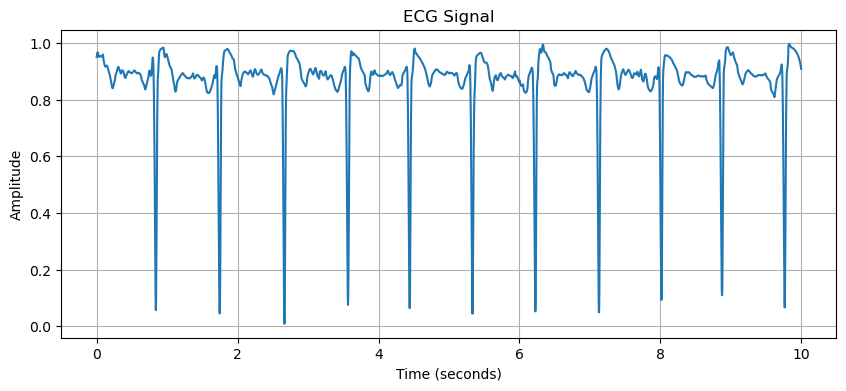

In [75]:
# Sampling frequency
sampling_freq = 300  # Hz

# Total number of readings
num_readings = 3000

# Time array (in seconds)
time = np.arange(num_readings) / sampling_freq

plt.figure(figsize=(10, 4))
plt.plot(time, ecg_set1['normalized_data'][5])
plt.title('ECG Signal')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

## Making the same modification to test data.

In [76]:
count = 0
for i in ecg_test['normalized_data']:
    ecg_test['normalized_data'][count] = i[0]
    count = count+1

In [476]:
column_names = ['File Names', 'normalized_data', 'length', 'label']
ecg_set2 = pd.DataFrame(columns=column_names)

In [467]:
count1 = 0
for i in ecg_test['normalized_data']:
    if len(i)>=18000:
        ecg_set2 = ecg_set2.append({'File Names': ecg_test['File Names'][count1],'normalized_data':i[0:3000],'length':3000, 'label': ecg_test['label'][count1] }, ignore_index=True)
        ecg_set2 = ecg_set2.append({'File Names': ecg_test['File Names'][count1],'normalized_data':i[3000:6000],'length':3000, 'label': ecg_test['label'][count1]}, ignore_index=True)
        ecg_set2 = ecg_set2.append({'File Names': ecg_test['File Names'][count1],'normalized_data':i[6000:9000],'length':3000, 'label': ecg_test['label'][count1]}, ignore_index=True)
        ecg_set2 = ecg_set2.append({'File Names': ecg_test['File Names'][count1],'normalized_data':i[9000:12000],'length':3000, 'label': ecg_test['label'][count1]}, ignore_index=True)
        ecg_set2 = ecg_set2.append({'File Names': ecg_test['File Names'][count1],'normalized_data':i[12000:15000],'length':3000, 'label': ecg_test['label'][count1]}, ignore_index=True)
        ecg_set2 = ecg_set2.append({'File Names': ecg_test['File Names'][count1],'normalized_data':i[15000:18000],'length':3000, 'label': ecg_test['label'][count1]}, ignore_index=True)
    elif len(i)>=15000:
        ecg_set2 = ecg_set2.append({'File Names': ecg_test['File Names'][count1],'normalized_data':i[0:3000],'length':3000, 'label': ecg_test['label'][count1]}, ignore_index=True)
        ecg_set2 = ecg_set2.append({'File Names': ecg_test['File Names'][count1],'normalized_data':i[3000:6000],'length':3000, 'label': ecg_test['label'][count1]}, ignore_index=True)
        ecg_set2 = ecg_set2.append({'File Names': ecg_test['File Names'][count1],'normalized_data':i[6000:9000],'length':3000, 'label': ecg_test['label'][count1]}, ignore_index=True)
        ecg_set2 = ecg_set2.append({'File Names': ecg_test['File Names'][count1],'normalized_data':i[9000:12000],'length':3000, 'label': ecg_test['label'][count1]}, ignore_index=True)
        ecg_set2 = ecg_set2.append({'File Names': ecg_test['File Names'][count1],'normalized_data':i[12000:15000],'length':3000, 'label': ecg_test['label'][count1]}, ignore_index=True)
    elif len(i)>=12000:
        ecg_set2 = ecg_set2.append({'File Names': ecg_test['File Names'][count1],'normalized_data':i[0:3000],'length':3000, 'label': ecg_test['label'][count1]}, ignore_index=True)
        ecg_set2 = ecg_set2.append({'File Names': ecg_test['File Names'][count1],'normalized_data':i[3000:6000],'length':3000, 'label': ecg_test['label'][count1]}, ignore_index=True)
        ecg_set2 = ecg_set2.append({'File Names': ecg_test['File Names'][count1],'normalized_data':i[6000:9000],'length':3000, 'label': ecg_test['label'][count1]}, ignore_index=True)
        ecg_set2 = ecg_set2.append({'File Names': ecg_test['File Names'][count1],'normalized_data':i[9000:12000],'length':3000, 'label': ecg_test['label'][count1]}, ignore_index=True)
    elif len(i)>=9000:
        ecg_set2 = ecg_set2.append({'File Names': ecg_test['File Names'][count1],'normalized_data':i[0:3000],'length':3000, 'label': ecg_test['label'][count1]}, ignore_index=True)
        ecg_set2 = ecg_set2.append({'File Names': ecg_test['File Names'][count1],'normalized_data':i[3000:6000],'length':3000, 'label': ecg_test['label'][count1]}, ignore_index=True)
        ecg_set2 = ecg_set2.append({'File Names': ecg_test['File Names'][count1],'normalized_data':i[6000:9000],'length':3000, 'label': ecg_test['label'][count1]}, ignore_index=True)
    elif len(i)>=6000:
        ecg_set2 = ecg_set2.append({'File Names': ecg_test['File Names'][count1],'normalized_data':i[0:3000],'length':3000, 'label': ecg_test['label'][count1]}, ignore_index=True)
        ecg_set2 = ecg_set2.append({'File Names': ecg_test['File Names'][count1],'normalized_data':i[3000:6000],'length':3000, 'label': ecg_test['label'][count1]}, ignore_index=True)
    elif len(i)>=3000:
        ecg_set2 = ecg_set2.append({'File Names': ecg_test['File Names'][count1],'normalized_data':i[0:3000],'length':3000, 'label': ecg_test['label'][count1]}, ignore_index=True)

    count1 = count1+1
        

In [477]:
count1 = 0
for i in ecg_test['normalized_data']:
    if len(i)>=18000:
        ecg_set2 = ecg_set2.append({'File Names': ecg_test['File Names'][count1],'normalized_data':i[0:3000],'length':3000, 'label': ecg_test['label'][count1] }, ignore_index=True)

    elif len(i)>=15000:
        ecg_set2 = ecg_set2.append({'File Names': ecg_test['File Names'][count1],'normalized_data':i[0:3000],'length':3000, 'label': ecg_test['label'][count1]}, ignore_index=True)
        
    elif len(i)>=12000:
        ecg_set2 = ecg_set2.append({'File Names': ecg_test['File Names'][count1],'normalized_data':i[0:3000],'length':3000, 'label': ecg_test['label'][count1]}, ignore_index=True)
        
    elif len(i)>=9000:
        ecg_set2 = ecg_set2.append({'File Names': ecg_test['File Names'][count1],'normalized_data':i[0:3000],'length':3000, 'label': ecg_test['label'][count1]}, ignore_index=True)
        
    elif len(i)>=6000:
        ecg_set2 = ecg_set2.append({'File Names': ecg_test['File Names'][count1],'normalized_data':i[0:3000],'length':3000, 'label': ecg_test['label'][count1]}, ignore_index=True)
        
    elif len(i)>=3000:
        ecg_set2 = ecg_set2.append({'File Names': ecg_test['File Names'][count1],'normalized_data':i[0:3000],'length':3000, 'label': ecg_test['label'][count1]}, ignore_index=True)

    count1 = count1+1
       

In [481]:
ecg_set2.head(10)

,File Names,normalized_data,length,label
0,A07690,"[0.6144615384615385, 0.6593846153846153, 0.68,...",3000,normal
1,A02930,"[0.17055655296229802, 0.18402154398563733, 0.1...",3000,normal
2,A03390,"[0.44107744107744107, 0.4696969696969697, 0.48...",3000,normal
3,A00699,"[0.16497263487099295, 0.13174354964816262, 0.0...",3000,other
4,A01587,"[0.6425582785415421, 0.661685594739988, 0.6832...",3000,other
5,A00855,"[0.25817361894024804, 0.2593010146561443, 0.26...",3000,other
6,A05093,"[0.18666666666666668, 0.14148148148148149, 0.0...",3000,other
7,A05911,"[0.4761571808138722, 0.47713606488602994, 0.47...",3000,other
8,A00869,"[0.34983766233766234, 0.3717532467532468, 0.39...",3000,af
9,A07860,"[0.3458294283036551, 0.3139643861293346, 0.279...",3000,af


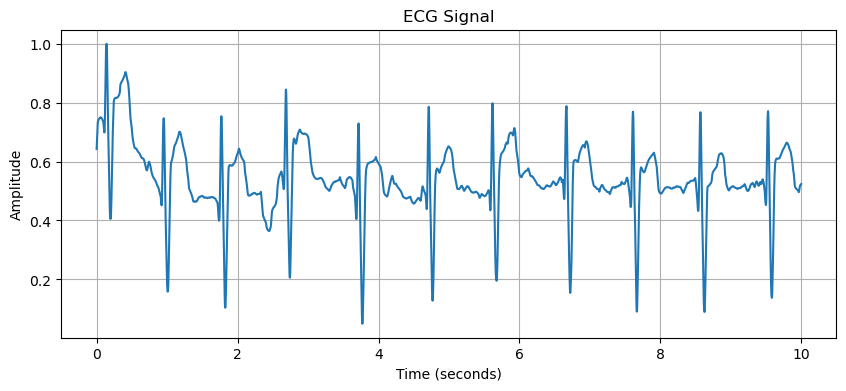

In [480]:
# Sampling frequency
sampling_freq = 300  # Hz

# Total number of readings
num_readings = 3000

# Time array (in seconds)
time = np.arange(num_readings) / sampling_freq

plt.figure(figsize=(10, 4))
plt.plot(time, ecg_set2['normalized_data'][4])
plt.title('ECG Signal')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

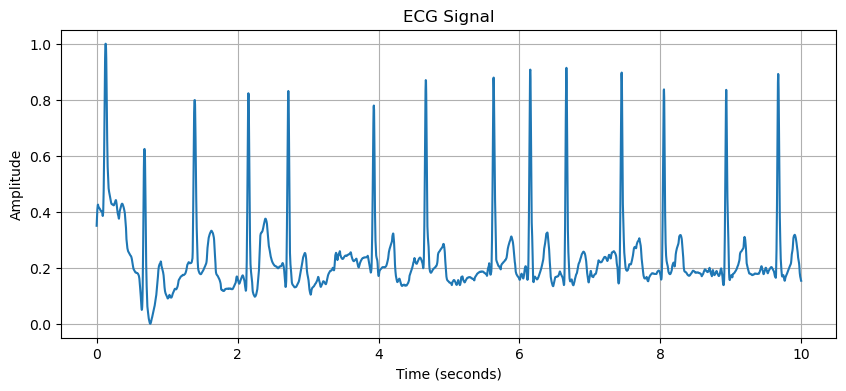

In [485]:
# Sampling frequency
sampling_freq = 300  # Hz

# Total number of readings
num_readings = 3000

# Time array (in seconds)
time = np.arange(num_readings) / sampling_freq

plt.figure(figsize=(10, 4))
plt.plot(time, ecg_set2['normalized_data'][8])
plt.title('ECG Signal')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

# Creating a Variational Auto Encoder.

In [380]:
x = np.vstack(ecg_set1['normalized_data'].values)

In [381]:
from sklearn.model_selection import train_test_split
x_train, x_val = train_test_split(x, test_size=0.2)

In [151]:
x_train.shape

(10108, 3000)

In [152]:
from __future__ import absolute_import
from __future__ import division
from __future__ import print_function

from tensorflow.keras.layers import Lambda, Input, Dense, LSTM
from tensorflow.keras.models import Model
from tensorflow.keras.losses import mse, binary_crossentropy
from tensorflow.keras.utils import plot_model
from tensorflow.keras import backend as K

import numpy as np
import matplotlib.pyplot as plt
import argparse
import os

In [153]:
def sampling(args):
    """Reparameterization trick by sampling from an isotropic unit Gaussian.
    # Arguments
        args (tensor): mean and log of variance of Q(z|X)
    # Returns
        z (tensor): sampled latent vector
    """

    z_mean, z_log_var = args
    batch = K.shape(z_mean)[0]
    dim = K.int_shape(z_mean)[1]
    # by default, random_normal has mean = 0 and std = 1.0
    epsilon = K.random_normal(shape=(batch, dim))
    return z_mean + K.exp(0.5 * z_log_var) * epsilon



In [154]:
input_shape = (3000, )
intermediate_dim = 512
batch_size = 128
latent_dim = 2
epochs = 50

Model: "encoder"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 encoder_input (InputLayer)     [(None, 3000)]       0           []                               
                                                                                                  
 dense_23 (Dense)               (None, 2048)         6146048     ['encoder_input[0][0]']          
                                                                                                  
 dense_24 (Dense)               (None, 1028)         2106372     ['dense_23[0][0]']               
                                                                                                  
 dense_25 (Dense)               (None, 512)          526848      ['dense_24[0][0]']               
                                                                                            

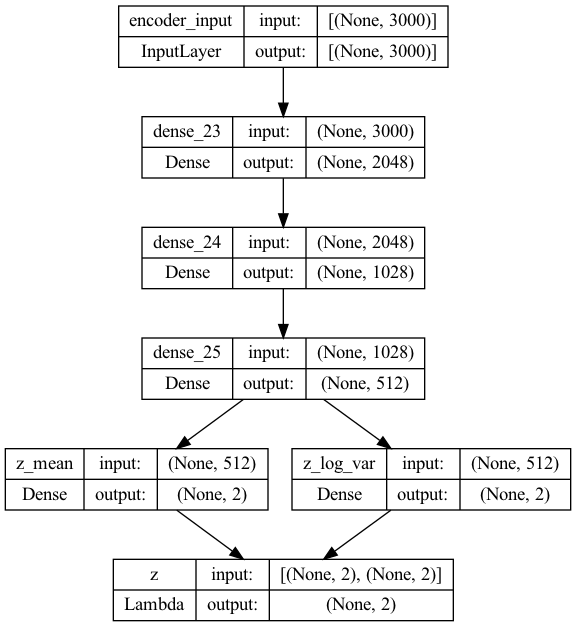

In [155]:
# build encoder model
inputs = Input(shape=input_shape, name='encoder_input')
inter = Dense(2048, activation = 'relu')(inputs)
inter1 = Dense(1028, activation = 'relu')(inter)
x = Dense(intermediate_dim, activation='relu')(inter1)
z_mean = Dense(latent_dim, name='z_mean')(x)
z_log_var = Dense(latent_dim, name='z_log_var')(x)

# use reparameterization trick to push the sampling out as input
# note that "output_shape" isn't necessary with the TensorFlow backend
z = Lambda(sampling, output_shape=(latent_dim,), name='z')([z_mean, z_log_var])

# instantiate encoder model
encoder = Model(inputs, [z_mean, z_log_var, z], name='encoder')
encoder.summary()
plot_model(encoder, show_shapes=True)


Model: "decoder"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 z_sampling (InputLayer)     [(None, 2)]               0         
                                                                 
 dense_26 (Dense)            (None, 512)               1536      
                                                                 
 dense_27 (Dense)            (None, 1028)              527364    
                                                                 
 dense_28 (Dense)            (None, 2048)              2107392   
                                                                 
 dense_29 (Dense)            (None, 3000)              6147000   
                                                                 
Total params: 8,783,292
Trainable params: 8,783,292
Non-trainable params: 0
_________________________________________________________________


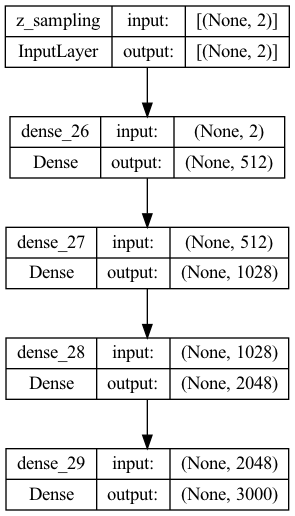

In [156]:
# build decoder model
latent_inputs = Input(shape=(latent_dim,), name='z_sampling')
x = Dense(intermediate_dim, activation='relu')(latent_inputs)
inter = Dense(1028, activation = 'relu')(x)
inter1 = Dense(2048, activation = 'relu')(inter)
outputs = Dense(3000, activation='sigmoid')(inter1)

# instantiate decoder model
decoder = Model(latent_inputs, outputs, name='decoder')
decoder.summary()
plot_model(decoder, show_shapes=True)

In [157]:
outputs = decoder(encoder(inputs)[2])
vae = Model(inputs, outputs, name='vae_mlp')

models = (encoder, decoder)
#data = (x_test, y_test)

reconstruction_loss = mse(inputs, outputs)

reconstruction_loss *= 3000
kl_loss = 1 + z_log_var - K.square(z_mean) - K.exp(z_log_var)
kl_loss = K.sum(kl_loss, axis=-1)
kl_loss *= -0.5
vae_loss = K.mean(reconstruction_loss + kl_loss)

vae.add_loss(vae_loss)
vae.compile(optimizer='adam')
vae.summary()

Model: "vae_mlp"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 encoder_input (InputLayer)     [(None, 3000)]       0           []                               
                                                                                                  
 encoder (Functional)           [(None, 2),          8781320     ['encoder_input[0][0]']          
                                 (None, 2),                                                       
                                 (None, 2)]                                                       
                                                                                                  
 decoder (Functional)           (None, 3000)         8783292     ['encoder[0][2]']                
                                                                                            

In [158]:
history = vae.fit(x_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(x_val, None))

Epoch 1/50
79/79 [==============================] - 6s 71ms/step - loss: 127.7994 - val_loss: 132.0897
Epoch 2/50
79/79 [==============================] - 6s 70ms/step - loss: 59.1004 - val_loss: 37.2966
Epoch 3/50
79/79 [==============================] - 6s 71ms/step - loss: 37.1144 - val_loss: 36.1936
Epoch 4/50
79/79 [==============================] - 5s 69ms/step - loss: 35.6086 - val_loss: 34.8896
Epoch 5/50
79/79 [==============================] - 6s 72ms/step - loss: 35.2722 - val_loss: 34.6700
Epoch 6/50
79/79 [==============================] - 6s 74ms/step - loss: 35.0355 - val_loss: 34.7798
Epoch 7/50
79/79 [==============================] - 6s 70ms/step - loss: 34.6169 - val_loss: 34.8491
Epoch 8/50
79/79 [==============================] - 6s 70ms/step - loss: 34.4804 - val_loss: 34.2324
Epoch 9/50
79/79 [==============================] - 6s 70ms/step - loss: 34.3893 - val_loss: 33.8144
Epoch 10/50
79/79 [==============================] - 6s 71ms/step - loss: 33.9955 - val_l

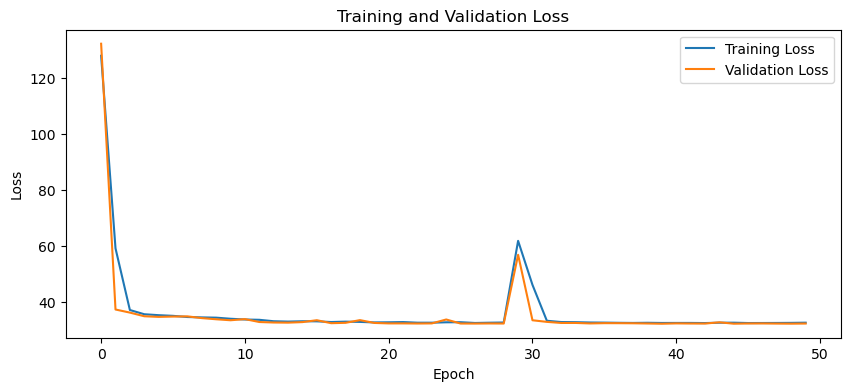

In [159]:
def plot_history(history):
    plt.figure(figsize=(10, 4))
    plt.plot(history['loss'], label='Training Loss')
    plt.plot(history['val_loss'], label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

plot_history(history.history)

In [446]:
pred = vae.predict(x_train)
print(pred)

316/316 [==============================] - 3s 9ms/step
[[0.4660736  0.4660935  0.46660492 ... 0.4667154  0.46573755 0.46559238]
 [0.4574599  0.45729697 0.45724168 ... 0.45758015 0.45756537 0.45731923]
 [0.312064   0.31450555 0.31516716 ... 0.30073196 0.30071524 0.3003855 ]
 ...
 [0.35408106 0.35637692 0.35680112 ... 0.34571594 0.34565994 0.34555987]
 [0.22438055 0.22530873 0.22776449 ... 0.20844132 0.2076656  0.20748165]
 [0.48866725 0.4873732  0.48616737 ... 0.49073598 0.49063385 0.49001744]]


In [447]:
difference = x_train - pred
squared = np.square(difference)
rec_loss = squared.sum(axis = 1)
rec_loss = np.sqrt(rec_loss)
#rec_loss = rec_loss.tolist()
print(rec_loss)

[5.83878953 4.30913925 5.93849555 ... 0.89126887 3.00583376 2.06308689]


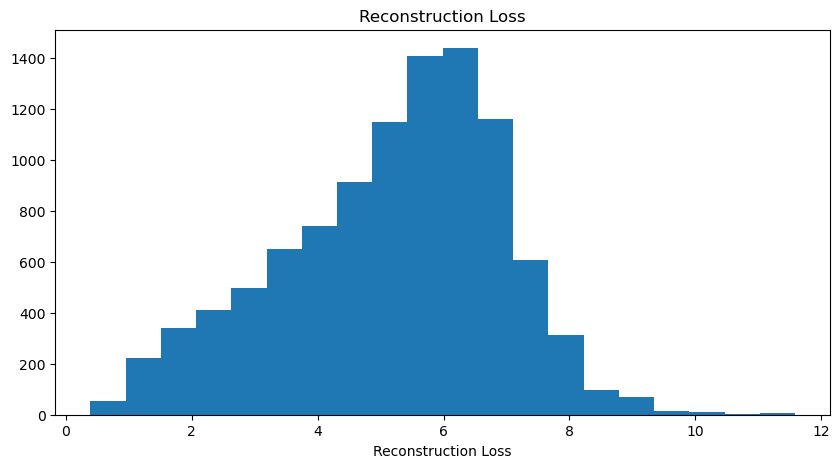

In [450]:
plt.hist(rec_loss, bins = 20)
plt.title('Reconstruction Loss')
plt.xlabel('Reconstruction Loss')
plt.show()

In [546]:
x_test = np.vstack(ecg_set2['normalized_data'].values)
pred = vae.predict(x_test)
difference = x_test - pred
squared = np.square(difference)
rec_loss = squared.sum(axis = 1)
rec_loss = np.sqrt(rec_loss)
rec_loss = rec_loss.tolist()
print(rec_loss)

140/140 [==============================] - 1s 10ms/step
[5.673774589553455, 7.154761198860749, 8.65025550463291, 4.726633407643624, 6.5493139088197365, 6.191598177248186, 6.920675082153544, 4.941068143085578, 7.157397619063943, 7.644941994224182, 6.643525572428819, 5.113292705680949, 7.103454345485838, 5.794869332532295, 6.196435672531674, 4.543928204677913, 6.51392416626776, 6.066348038627044, 8.118922566205283, 3.27984538659096, 2.6277702758785995, 5.973624284904257, 6.393575294352907, 8.620607477292465, 4.474064947365303, 5.884949909815885, 7.326264058767917, 6.174297051560904, 4.694755666688557, 3.5605683351007906, 6.812346248921046, 3.9961161955626974, 3.3242625086631206, 4.66511267144728, 7.215996073390367, 8.53052359716019, 7.107506803707761, 5.59636859226206, 5.522254582850412, 7.47844480070588, 6.479933964101608, 7.0144731337649695, 6.110764109915562, 6.256113662219335, 6.3756793975112, 7.2038351289358795, 6.745406852250207, 5.714195720938088, 6.7507233189606835, 4.98116949024

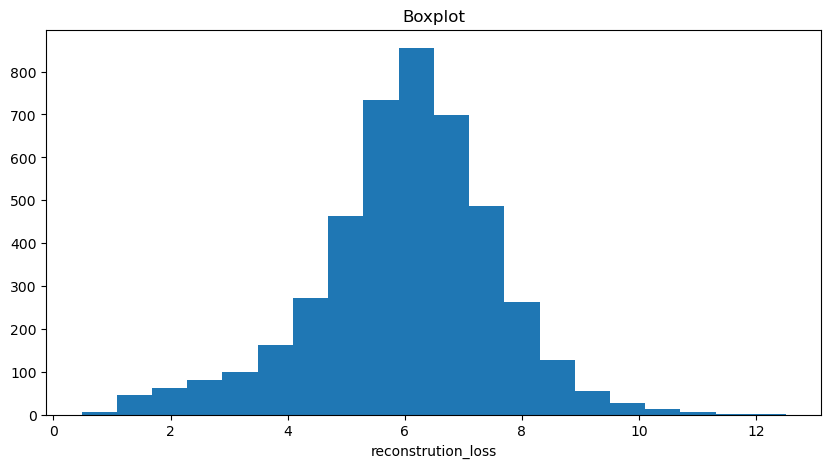

In [553]:
plt.hist(rec_loss, bins = 20)
plt.title('Boxplot')
plt.xlabel('reconstrution_loss')
plt.show()

In [554]:
pred_labels = []
for i in rec_loss:
    if i>6:
        pred_labels.append('abnormanl')
    elif i<6:
        pred_labels.append('normal')
pred_labels[:10]

['normal',
 'abnormanl',
 'abnormanl',
 'normal',
 'abnormanl',
 'abnormanl',
 'abnormanl',
 'normal',
 'abnormanl',
 'abnormanl']

In [555]:
ecg_set2['pred_labels'] = pred_labels
ecg_set2.shape

(4461, 6)

In [556]:
ecg_set2['pred_labels'].value_counts()

abnormanl    2376
normal       2085
Name: pred_labels, dtype: int64

In [557]:
ecg_set2['label'].value_counts()

abnormanl    3446
normal       1015
Name: label, dtype: int64

In [558]:
ecg_set2['labels'] = ecg_set2['label']

In [559]:
ecg_set2['label'] = ecg_set2['label'].replace({'other': 'abnormanl', 'af': 'abnormanl', 'noisy':'abnormanl'})

In [560]:
acc = 0
count = 0
corr = 0
length = 4461
for i in ecg_set2['pred_labels']:
    
    if i == ecg_set2['label'][count]:
        corr = corr+1
    else:
        continue
    count = count+1
acc = corr/length
print(acc)

0.5072853620264515


In [461]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score

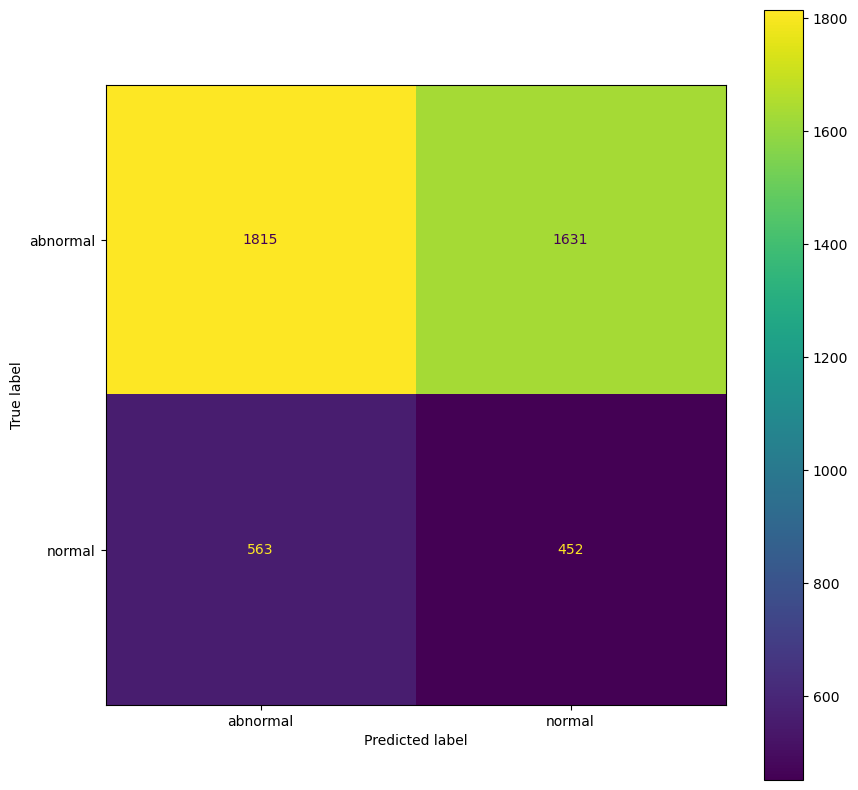

In [524]:
fig = plt.figure(figsize=[10, 10])
ax = fig.add_subplot(1, 1, 1)
cf = confusion_matrix(ecg_set2['label'], ecg_set2['pred_labels'])
c = ConfusionMatrixDisplay(cf, display_labels=['abnormal', 'normal'] )
c.plot(ax=ax)

In [185]:
precision = precision_score(ecg_set2['label'], ecg_set2['pred_labels'])
recall = recall_score(ecg_set2['label'], ecg_set2['pred_labels'])
f1 = f1_score(ecg_set2['label'], ecg_set2['pred_labels'])
print(precision, recall, f1)

ValueError: pos_label=1 is not a valid label. It should be one of ['abnormanl', 'normal']

## Creating Auto-encoder

In [189]:
column_names = ['File Names', 'normalized_data', 'length']
ecg_set1 = pd.DataFrame(columns=column_names)
#ecg_set2 = pd.DataFrame(columns=column_names)
print(ecg_set1.shape)
#print(ecg_set2.shape)

(0, 3)


In [190]:
# Subset 1
count1 = 0
for i in ecg_df['normalized_data']:
    if len(i)>=18000:
        ecg_set1 = ecg_set1.append({'File Names': ecg_df['File Names'][count1],'normalized_data':i[0:3000],'length':3000}, ignore_index=True)
        ecg_set1 = ecg_set1.append({'File Names': ecg_df['File Names'][count1],'normalized_data':i[3000:6000],'length':3000}, ignore_index=True)
        ecg_set1 = ecg_set1.append({'File Names': ecg_df['File Names'][count1],'normalized_data':i[6000:9000],'length':3000}, ignore_index=True)
        ecg_set1 = ecg_set1.append({'File Names': ecg_df['File Names'][count1],'normalized_data':i[9000:12000],'length':3000}, ignore_index=True)
        ecg_set1 = ecg_set1.append({'File Names': ecg_df['File Names'][count1],'normalized_data':i[12000:15000],'length':3000}, ignore_index=True)
        ecg_set1 = ecg_set1.append({'File Names': ecg_df['File Names'][count1],'normalized_data':i[15000:18000],'length':3000}, ignore_index=True)
    elif len(i)>=15000:
        ecg_set1 = ecg_set1.append({'File Names': ecg_df['File Names'][count1],'normalized_data':i[0:3000],'length':3000}, ignore_index=True)
        ecg_set1 = ecg_set1.append({'File Names': ecg_df['File Names'][count1],'normalized_data':i[3000:6000],'length':3000}, ignore_index=True)
        ecg_set1 = ecg_set1.append({'File Names': ecg_df['File Names'][count1],'normalized_data':i[6000:9000],'length':3000}, ignore_index=True)
        ecg_set1 = ecg_set1.append({'File Names': ecg_df['File Names'][count1],'normalized_data':i[9000:12000],'length':3000}, ignore_index=True)
        ecg_set1 = ecg_set1.append({'File Names': ecg_df['File Names'][count1],'normalized_data':i[12000:15000],'length':3000}, ignore_index=True)
    elif len(i)>=12000:
        ecg_set1 = ecg_set1.append({'File Names': ecg_df['File Names'][count1],'normalized_data':i[0:3000],'length':3000}, ignore_index=True)
        ecg_set1 = ecg_set1.append({'File Names': ecg_df['File Names'][count1],'normalized_data':i[3000:6000],'length':3000}, ignore_index=True)
        ecg_set1 = ecg_set1.append({'File Names': ecg_df['File Names'][count1],'normalized_data':i[6000:9000],'length':3000}, ignore_index=True)
        ecg_set1 = ecg_set1.append({'File Names': ecg_df['File Names'][count1],'normalized_data':i[9000:12000],'length':3000}, ignore_index=True)
    elif len(i)>=9000:
        ecg_set1 = ecg_set1.append({'File Names': ecg_df['File Names'][count1],'normalized_data':i[0:3000],'length':3000}, ignore_index=True)
        ecg_set1 = ecg_set1.append({'File Names': ecg_df['File Names'][count1],'normalized_data':i[3000:6000],'length':3000}, ignore_index=True)
        ecg_set1 = ecg_set1.append({'File Names': ecg_df['File Names'][count1],'normalized_data':i[6000:9000],'length':3000}, ignore_index=True)
    elif len(i)>=6000:
        ecg_set1 = ecg_set1.append({'File Names': ecg_df['File Names'][count1],'normalized_data':i[0:3000],'length':3000}, ignore_index=True)
        ecg_set1 = ecg_set1.append({'File Names': ecg_df['File Names'][count1],'normalized_data':i[3000:6000],'length':3000}, ignore_index=True)
    elif len(i)>=3000:
        ecg_set1 = ecg_set1.append({'File Names': ecg_df['File Names'][count1],'normalized_data':i[0:3000],'length':3000}, ignore_index=True)

    count1 = count1+1
        

In [191]:
x_train = np.vstack(ecg_set1['normalized_data'].values)

In [192]:
x_train, x_val = train_test_split(x_train, test_size=0.2)

In [193]:
inputs = Input(shape=(3000,))
encoded = Dense(2048, activation='relu')(inputs)
encoded = Dense(1028, activation='relu')(encoded)
encoded = Dense(512, activation='relu')(encoded)
# add a Dense layer with a L1 activity regularizer
#encoded = Dense(encoding_dim, activation='relu', name='bottleneck',
#                activity_regularizer=regularizers.l1(10e-5))(encoded)
encoded = Dense(256, activation='relu')(encoded)
decoded = Dense(512, activation='relu')(encoded)
decoded = Dense(1028, activation='relu')(decoded)
decoded = Dense(2048, activation='sigmoid')(decoded)
decoded = Dense(3000, activation='sigmoid')(decoded)
autoencoder = Model(inputs, decoded)
autoencoder.compile(optimizer='adam', loss='mean_squared_error')
autoencoder.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_8 (InputLayer)        [(None, 3000)]            0         
                                                                 
 dense_30 (Dense)            (None, 2048)              6146048   
                                                                 
 dense_31 (Dense)            (None, 1028)              2106372   
                                                                 
 dense_32 (Dense)            (None, 512)               526848    
                                                                 
 dense_33 (Dense)            (None, 256)               131328    
                                                                 
 dense_34 (Dense)            (None, 512)               131584    
                                                                 
 dense_35 (Dense)            (None, 1028)              5273

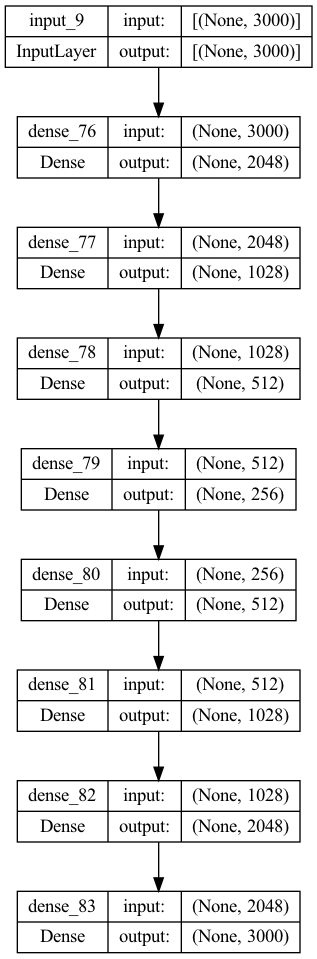

In [432]:
plot_model(autoencoder, show_shapes=True)

In [194]:
history = autoencoder.fit(x_train, x_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(x_val, x_val))

Epoch 1/50
79/79 [==============================] - 5s 60ms/step - loss: 0.0191 - val_loss: 0.0124
Epoch 2/50
79/79 [==============================] - 5s 60ms/step - loss: 0.0118 - val_loss: 0.0110
Epoch 3/50
79/79 [==============================] - 5s 60ms/step - loss: 0.0110 - val_loss: 0.0107
Epoch 4/50
79/79 [==============================] - 5s 59ms/step - loss: 0.0108 - val_loss: 0.0105
Epoch 5/50
79/79 [==============================] - 5s 59ms/step - loss: 0.0107 - val_loss: 0.0104
Epoch 6/50
79/79 [==============================] - 5s 60ms/step - loss: 0.0106 - val_loss: 0.0106
Epoch 7/50
79/79 [==============================] - 5s 60ms/step - loss: 0.0105 - val_loss: 0.0104
Epoch 8/50
79/79 [==============================] - 5s 59ms/step - loss: 0.0105 - val_loss: 0.0103
Epoch 9/50
79/79 [==============================] - 5s 60ms/step - loss: 0.0104 - val_loss: 0.0102
Epoch 10/50
79/79 [==============================] - 5s 60ms/step - loss: 0.0104 - val_loss: 0.0102
Epoch 11/

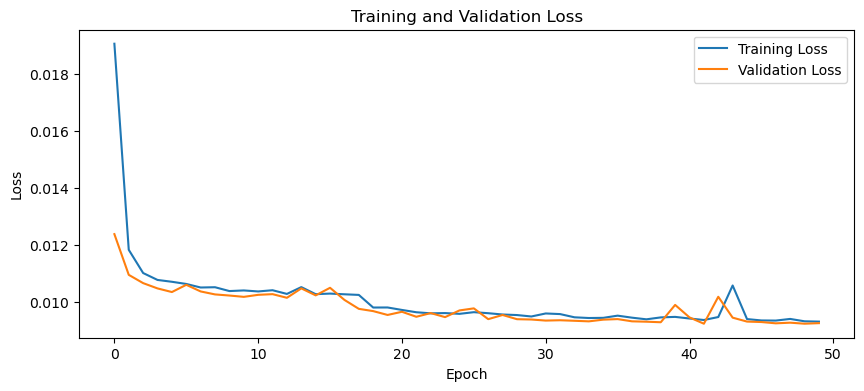

In [195]:
plot_history(history.history)

In [423]:
pred = autoencoder.predict(x_train)
difference = x_train - pred
squared = np.square(difference)
rec_loss = squared.sum(axis = 1)
rec_loss = np.sqrt(rec_loss)
rec_loss = rec_loss.tolist()
print(rec_loss[:20])

316/316 [==============================] - 3s 9ms/step
[5.210508899747796, 4.393189231336482, 6.0183251814389545, 8.3793910387352, 6.537579915816861, 4.273285357061237, 4.7194094836834335, 1.6416546370763974, 3.3198697500554903, 0.9281747349235583, 4.081156367333773, 6.395487340621144, 3.092370463164072, 2.3975521607303865, 3.6321973565531698, 3.1344674823198524, 3.2696315256296096, 4.506146126830157, 2.502609248564223, 6.872161466170398]


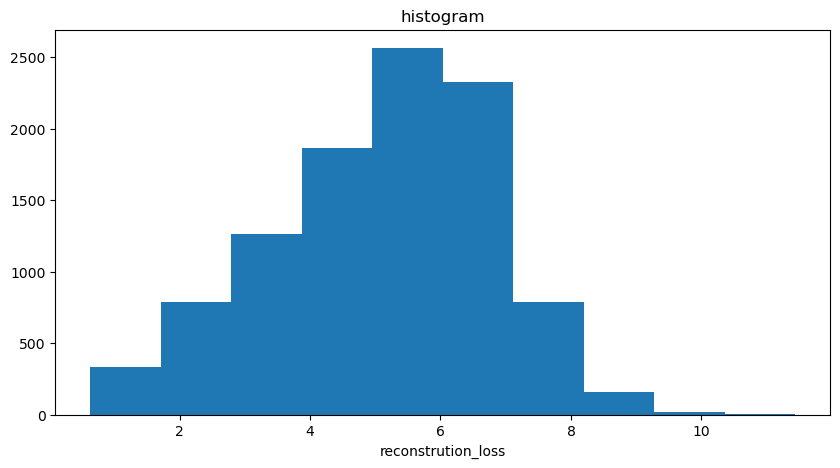

In [424]:
plt.hist(rec_loss)
plt.title('histogram')
plt.xlabel('reconstrution_loss')
plt.show()

In [425]:
len(rec_loss)

10108

In [319]:
outliers = 0
for i in rec_loss:
    if i < 0.015:
        outliers = outliers+1
    else:
        continue
print(outliers)

8594


In [200]:
pred_labels = []
for i in rec_loss:
    if i>0.012:
        pred_labels.append('abnormanl')
    elif i<0.012:
        pred_labels.append('normal')
print(pred_labels[:10])
print(len(pred_labels))

['normal', 'abnormanl', 'normal', 'abnormanl', 'abnormanl', 'normal', 'normal', 'normal', 'normal', 'normal']
10108


In [201]:
ecg_set1.head(10)

,File Names,normalized_data,length
0,A07848,"[0.14116002795248078, 0.10656883298392732, 0.0...",3000
1,A07848,"[0.30782669461914747, 0.30992313067784766, 0.3...",3000
2,A07848,"[0.2973445143256464, 0.2994409503843466, 0.302...",3000
3,A04399,"[0.9026602176541717, 0.903869407496977, 0.9068...",3000
4,A04399,"[0.966142684401451, 0.9655380894800484, 0.9643...",3000
5,A04399,"[0.9504232164449818, 0.9558645707376058, 0.960...",3000
6,A05087,"[0.49218261413383363, 0.5265791119449656, 0.56...",3000
7,A05087,"[0.4058786741713571, 0.4058786741713571, 0.405...",3000
8,A05087,"[0.4046278924327705, 0.3533458411507192, 0.325...",3000
9,A05939,"[0.4492512479201331, 0.44841930116472545, 0.44...",3000


In [536]:
x_test = np.vstack(ecg_set2['normalized_data'].values)
pred = autoencoder.predict(x_test)
difference = x_test - pred
squared = np.square(difference)
rec_loss = squared.sum(axis = 1)
rec_loss = np.sqrt(rec_loss)
rec_loss = rec_loss.tolist()
print(rec_loss[:10])

140/140 [==============================] - 1s 9ms/step
[4.973809594740684, 7.538561893456128, 8.64248117339675, 4.086999160686047, 6.081956549386151, 6.226249749220543, 6.921486207000797, 4.949302520251143, 6.627684277282472, 7.038849788274539]


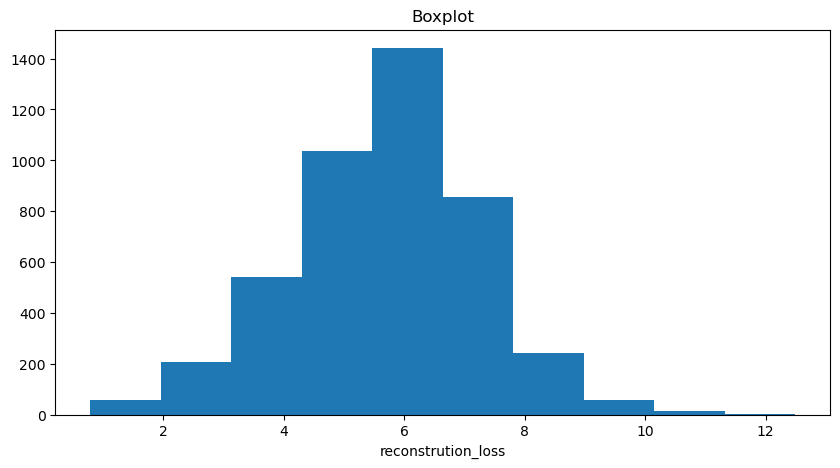

In [537]:
plt.hist(rec_loss)
plt.title('Boxplot')
plt.xlabel('reconstrution_loss')
plt.show()

In [542]:
pred_labels = []
for i in rec_loss:
    if i>6:
        pred_labels.append('abnormanl')
    elif i<6:
        pred_labels.append('normal')
pred_labels[:10]

['normal',
 'abnormanl',
 'abnormanl',
 'normal',
 'abnormanl',
 'abnormanl',
 'abnormanl',
 'normal',
 'abnormanl',
 'abnormanl']

In [543]:
ecg_set2['pred_labels'] = pred_labels
ecg_set2.shape

(4461, 6)

In [544]:
acc = 0
count = 0
corr = 0
length = 4461
for i in ecg_set2['pred_labels']:
    
    if i == ecg_set2['label'][count]:
        corr = corr+1
    else:
        continue
    count = count+1
acc = corr/length
print(acc)

0.45796906523201075


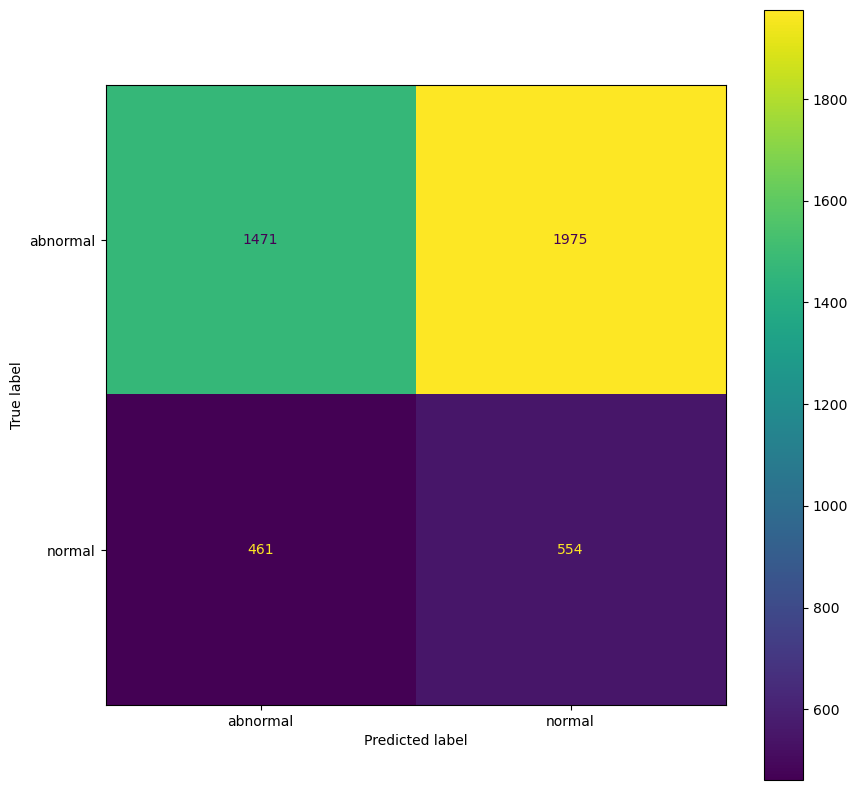

In [545]:
fig = plt.figure(figsize=[10, 10])
ax = fig.add_subplot(1, 1, 1)
cf = confusion_matrix(ecg_set2['label'], ecg_set2['pred_labels'])
c = ConfusionMatrixDisplay(cf, display_labels=['abnormal', 'normal'] )
c.plot(ax=ax)